In [1]:
%matplotlib inline

In [83]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm.notebook import tqdm

def make_subspace_blobs(p_dim=0.7,rep=3,p_rand=0.1,**blobs_params):
    """
    Parameters
    ----------
    p_dim : float, default=0.7
        Proportion of noise dimensions in clusters
    **blobs_params : named parameters
        Parameters from the sklearn.datasets.blobs_params function

    Returns
    -------
    np.ndarray
        Dataset generated
    np.ndarray
        cluster memberships
    np.ndarray
        True cluster subspaces

    Examples:
    ---------
        >>> import seaborn as sns
        >>> import matplotlib.pyplot as plt
        >>> import pandas as pd
        >>> X,y_true,subspaces = make_subspace_blobs()
        >>> X_df = pd.DataFrame(X)
        >>> X_df["cluster"] = y_true
        >>> sns.scatterplot(x=0, y=1, hue="cluster", marker=".", data=X_df)
        >>> plt.show()
        >>> sns.heatmap(subspaces)
        >>> plt.show()
    """
    default_blobs_params = {"n_samples":1000,
                            "n_features":10,
                            "centers":5,
                            "cluster_std":1.0,
                            "center_box":(-10.0, 10.0),
                            "shuffle":True,
                            "random_state":None,}
    default_blobs_params.update(blobs_params)
    X,y_true = make_blobs(**default_blobs_params)
    subspaces = np.random.binomial(size=(default_blobs_params["centers"],
                                         default_blobs_params["n_features"]),
                                   p=1 - p_dim,
                                   n=1)
    cols = [str(i)+":0" for i in range(X.shape[1])]
    X = pd.DataFrame(X,columns=cols)
    subspaces = pd.DataFrame(subspaces,columns=cols)

    # add repetitions
    for c in X.columns:
        for i in range(1,rep):
            X[c[:-1]+str(i+1)] = X[c]
            subspaces[c[:-1]+str(i+1)] = subspaces[c]
    X += np.random.randn(*X.shape)
    # uniform elements for random conditions
    uniform_coordinates = np.random.uniform(low=default_blobs_params["center_box"][0],
                                            high=default_blobs_params["center_box"][1],
                                            size=X.shape)
    X_rand_subspaces =  subspaces.values[y_true,:]
    X *= np.logical_not(X_rand_subspaces)
    X += uniform_coordinates*X_rand_subspaces
    ss = pd.DataFrame(np.logical_not(subspaces))
    # add noise points
    # Add noise points
    n_rand = int(p_rand * X.shape[0])
    to_noise = np.random.choice(X.shape[0],n_rand,replace=False)
    X.iloc[to_noise,:] = np.random.uniform(-10,10,(n_rand,X.shape[1]))
    y_true[to_noise]=-1
    X = X.sort_index(axis=1)
    ss = ss.sort_index(axis=1)
    return(X,y_true,ss)

In [53]:
X,y_true,ss = make_subspace_blobs(p_dim=0.9,rep=1,p_rand=0.1)
X.columns = range(len(X.columns))

In [379]:
X_d = discretize_genexp(X,"ewd",20,axis=0)

In [380]:
from grenadine.Preprocessing.discretization import discretize_genexp

In [381]:
def flatten_set(elements):
    flat = []
    for e in list(elements):
        if type(e) == tuple:
            flat+=flatten_set(e)
        elif type(e) == str:
            flat.append(e)
    flat = tuple(set(flat))
    return(flat)
        
    
class learner:
    def __init__(self,decay=0.03,activation=0.1,learning_rate=0.3,depth=1,forget_threshold=0,init_memory_len=2):
        self.decay = decay
        self.learning_rate = learning_rate
        self.activation = activation
        self.forget_threshold = forget_threshold    
        self.init_memory_len = init_memory_len
        self.depth = depth
        self.rules = {}
        self.elements = []
        self.input_elements = []
        
    def reinforcement(self):
        best_f1 = -1
        best_rule = -1
        for d in range(self.depth):
            for r in self.rules:
                f1 = self.F1(self.input_elements,r)
                #print(self.input_elements,r,f1)
                if best_f1 < f1:
                    best_f1 = f1
                    best_rule = r
                if f1 > self.activation:
                    self.elements = set(list(self.elements)+[r])
            if best_rule in self.rules:
                self.rules[best_rule] += best_f1*self.learning_rate
                self.split(self.elements,best_rule)
                self.join(self.input_elements,best_rule)
                print("_____",best_rule,best_f1)
                #print(self.rules)
    
    def F1(self,elements,rules):
        tp = elements.intersection(rules)
        precision = len(tp)/len(elements)
        recall = len(tp)/len(rules)
        f1 = 2*precision*recall/(precision+recall+1e-10)
        return(f1)
                
    def split(self,elements,rule):
        tp = elements.intersection(rule)
        tn = set(rule).difference(elements)
        if len(tp) != len(rule) and len(tp):
            self.rules[tuple(tp)] = self.F1(elements,tp)
            self.rules[tuple(tn)] = 0
        
    def join(self, elements, rule):
        new_rule = flatten_set(rule)
        self.rules[new_rule] = self.F1(elements,new_rule)
        print(new_rule)
    
    def forget(self):
        forget_rules = []
        for r in self.rules:
            self.rules[r] -= self.decay
            if self.rules[r] < self.forget_threshold:
                forget_rules.append(r)
        for r in forget_rules:
            self.rules.pop(r)
            
    def learn(self,elements):
        self.elements = elements
        self.input_elements = elements
        self.reinforcement()
        self.forget()
        self.new_memory()
        
    def new_memory(self):
        r = set(random.sample(self.elements,self.init_memory_len))
        r = flatten_set(tuple(r))
        self.rules[r] = self.F1(self.input_elements, r)*self.learning_rate
        


In [382]:
set.union(*[set(["x_2"]), set(["x-1","x3",tuple(["x_44","sfsf"])])])

{('x_44', 'sfsf'), 'x-1', 'x3', 'x_2'}

In [383]:
l = learner()
for i in tqdm(X_d.index):
    elements = set([str(d)+"_"+str(X_d.loc[i,d]) for d in X_d.columns])
    l.learn(elements)

('9_13', '6_13')
_____ ('9_13', '6_13') 0.1666666666388889
('9_13', '6_13')
_____ ('9_13', '6_13') 0.0
('6_13',)
_____ ('6_13',) 0.0
('1_16', '6_16')
_____ ('1_16', '6_16') 0.1666666666388889
('2_11', '7_9')
_____ ('2_11', '7_9') 0.1666666666388889
('6_16',)
_____ ('6_16',) 0.18181818180165288
('8_9', '5_16')
_____ ('8_9', '5_16') 0.1666666666388889
('0_13', '3_1')
_____ ('0_13', '3_1') 0.1666666666388889
('2_6', '6_12')
_____ ('2_6', '6_12') 0.1666666666388889
('6_12',)
_____ ('6_12',) 0.18181818180165288
('8_9', '5_16')
_____ ('8_9', '5_16') 0.0
('6_16',)
_____ ('6_16',) 0.0
('0_13', '3_1')
_____ ('0_13', '3_1') 0.0
('6_12',)
_____ ('6_12',) 0.18181818180165288
('8_2', '4_13')
_____ ('8_2', '4_13') 0.1666666666388889
('6_12',)
_____ ('6_12',) 0.0
('8_2', '4_13')
_____ ('8_2', '4_13') 0.0
('1_9', '3_14')
_____ ('1_9', '3_14') 0.1666666666388889
('4_13',)
_____ ('4_13',) 0.0
('8_14', '6_14')
_____ ('8_14', '6_14') 0.1666666666388889
('1_9',)
_____ ('1_9',) 0.18181818180165288
('3_13', 

('9_14', '3_14')
_____ ('9_14', '3_14') 0.1666666666388889
('9_17',)
_____ ('9_17',) 0.0
('2_10', '0_10')
_____ ('2_10', '0_10') 0.3333333333055556
('5_14', '0_10')
_____ ('5_14', '0_10') 0.0
('0_10',)
_____ ('0_10',) 0.18181818180165288
('9_14', '3_14')
_____ ('9_14', '3_14') 0.0
('1_10', '0_14')
_____ ('1_10', '0_14') 0.1666666666388889
('0_10',)
_____ ('0_10',) 0.0
('0_11', '3_4')
_____ ('0_11', '3_4') 0.1666666666388889
('1_10', '0_14')
_____ ('1_10', '0_14') 0.1666666666388889
('0_11',)
_____ ('0_11',) 0.18181818180165288
('1_7', '3_15')
_____ ('1_7', '3_15') 0.1666666666388889
('2_10', '0_10')
_____ ('2_10', '0_10') 0.1666666666388889
('2_10',)
_____ ('2_10',) 0.18181818180165288
('2_10', '0_10')
_____ ('2_10', '0_10') 0.0
('0_11',)
_____ ('0_11',) 0.0
('3_15',)
_____ ('3_15',) 0.0
('2_10',)
_____ ('2_10',) 0.0
('0_9', '1_6')
_____ ('1_6', '0_9') 0.0
('8_9', '4_11')
_____ ('8_9', '4_11') 0.0
('3_3', '9_9')
_____ ('3_3', '9_9') 0.0
('3_13', '0_11')
_____ ('3_13', '0_11') 0.0
('3_1

_____ ('3_12',) 0.0
('3_12', '8_6')
_____ ('3_12', '8_6') 0.1666666666388889
('7_8', '8_12')
_____ ('7_8', '8_12') 0.1666666666388889
('7_8', '8_12')
_____ ('7_8', '8_12') 0.0
('3_12', '9_13')
_____ ('3_12', '9_13') 0.3333333333055556
('7_8',)
_____ ('7_8',) 0.18181818180165288
('3_12',)
_____ ('3_12',) 0.18181818180165288
('3_12', '9_13', '2_12')
_____ ('3_12', '9_13', '2_12') 0.15384615381065087
('3_12',)
_____ ('3_12',) 0.0
('3_13', '4_13')
_____ ('3_13', '4_13') 0.1666666666388889
('0_13', '2_7')
_____ ('0_13', '2_7') 0.1666666666388889
('7_8',)
_____ ('7_8',) 0.0
('3_13',)
_____ ('3_13',) 0.18181818180165288
('0_11', '6_16')
_____ ('0_11', '6_16') 0.1666666666388889
('3_13', '4_13')
_____ ('3_13', '4_13') 0.0
('0_13',)
_____ ('0_13',) 0.18181818180165288
('0_13',)
_____ ('0_13',) 0.18181818180165288
('3_13',)
_____ ('3_13',) 0.0
('6_14', '3_4')
_____ ('6_14', '3_4') 0.1666666666388889
('6_14', '4_13')
_____ ('6_14', '4_13') 0.1666666666388889
('0_13',)
_____ ('0_13',) 0.0
('6_14',

In [384]:
len(l.rules)

9

In [385]:
for r in l.rules:
    print(l.rules[r])

0.01666666663888891
0.15181818180165288
0.12181818180165288
0.04666666663888891
0.04666666665138891
0.009999999991666675
0.039999999991666674
0.06999999999166667
0.09999999999166667


In [386]:
l.rules

{('4_11', '3_15'): 0.01666666663888891,
 ('3_12',): 0.15181818180165288,
 ('4_11',): 0.12181818180165288,
 ('2_10', '5_4'): 0.04666666663888891,
 ('2_10',): 0.04666666665138891,
 ('0_11', '2_10'): 0.009999999991666675,
 ('3_12', '4_7'): 0.039999999991666674,
 ('2_11', '5_11'): 0.06999999999166667,
 ('8_17', '1_16'): 0.09999999999166667}

In [387]:


y_true[np.logical_and(np.logical_and(X_d[3]==6,X_d[6]==7),X_d[1]==8)]

array([], dtype=int64)

/Users/sergiopeignier/anaconda3/lib/python3.7/site-packages/seaborn/matrix.py:624: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


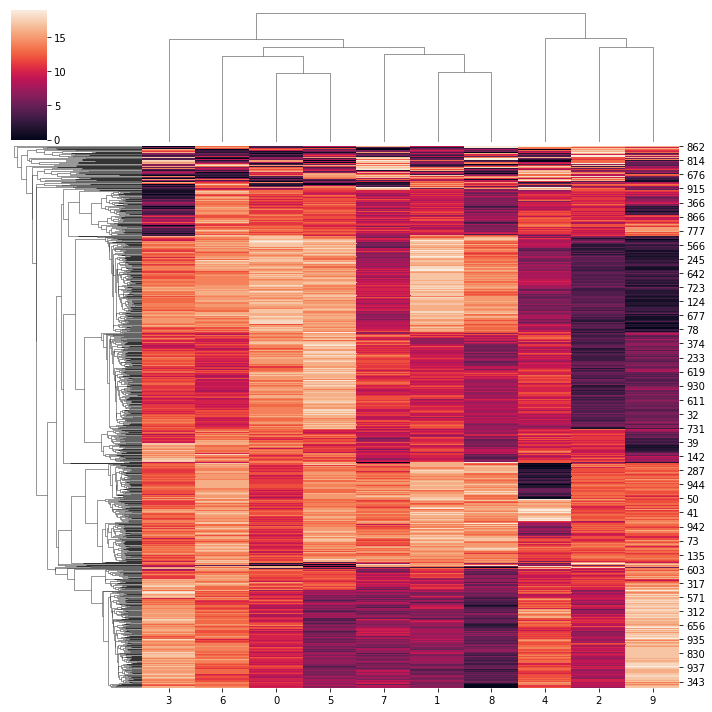

In [388]:
sns.clustermap(X_d)

In [389]:
from mlxtend.frequent_patterns import fpmax
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder


In [390]:
transactions = [[str(d)+"_"+str(X_d.loc[i,d]) for d in X_d.columns] for i in X_d.index]
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

In [396]:
fpmax(df,min_support=0.1,use_colnames=True)

,support,itemsets
0,0.101,(2_12)
1,0.102,(7_7)
2,0.102,(3_11)
3,0.111,(8_14)
4,0.111,(0_13)
5,0.112,(5_14)
6,0.113,(6_16)
7,0.113,(8_7)
8,0.116,(1_16)
9,0.116,(1_9)
